#### __Exercise 1__

Read in the `housing.csv` data, and examine it for nulls.

In [2]:
#Answer here
import pandas as pd
df = pd.read_csv("./data/housing.csv")

print(df.shape)
print(df.isna().sum())
df.head()

(20640, 10)
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### **Exercise 2**

Using pandas, take a random sample of 5000 rows and plot a `scatter_matrix`.  What stands out to you?  Why?  (Provide your narrative response as markdown).

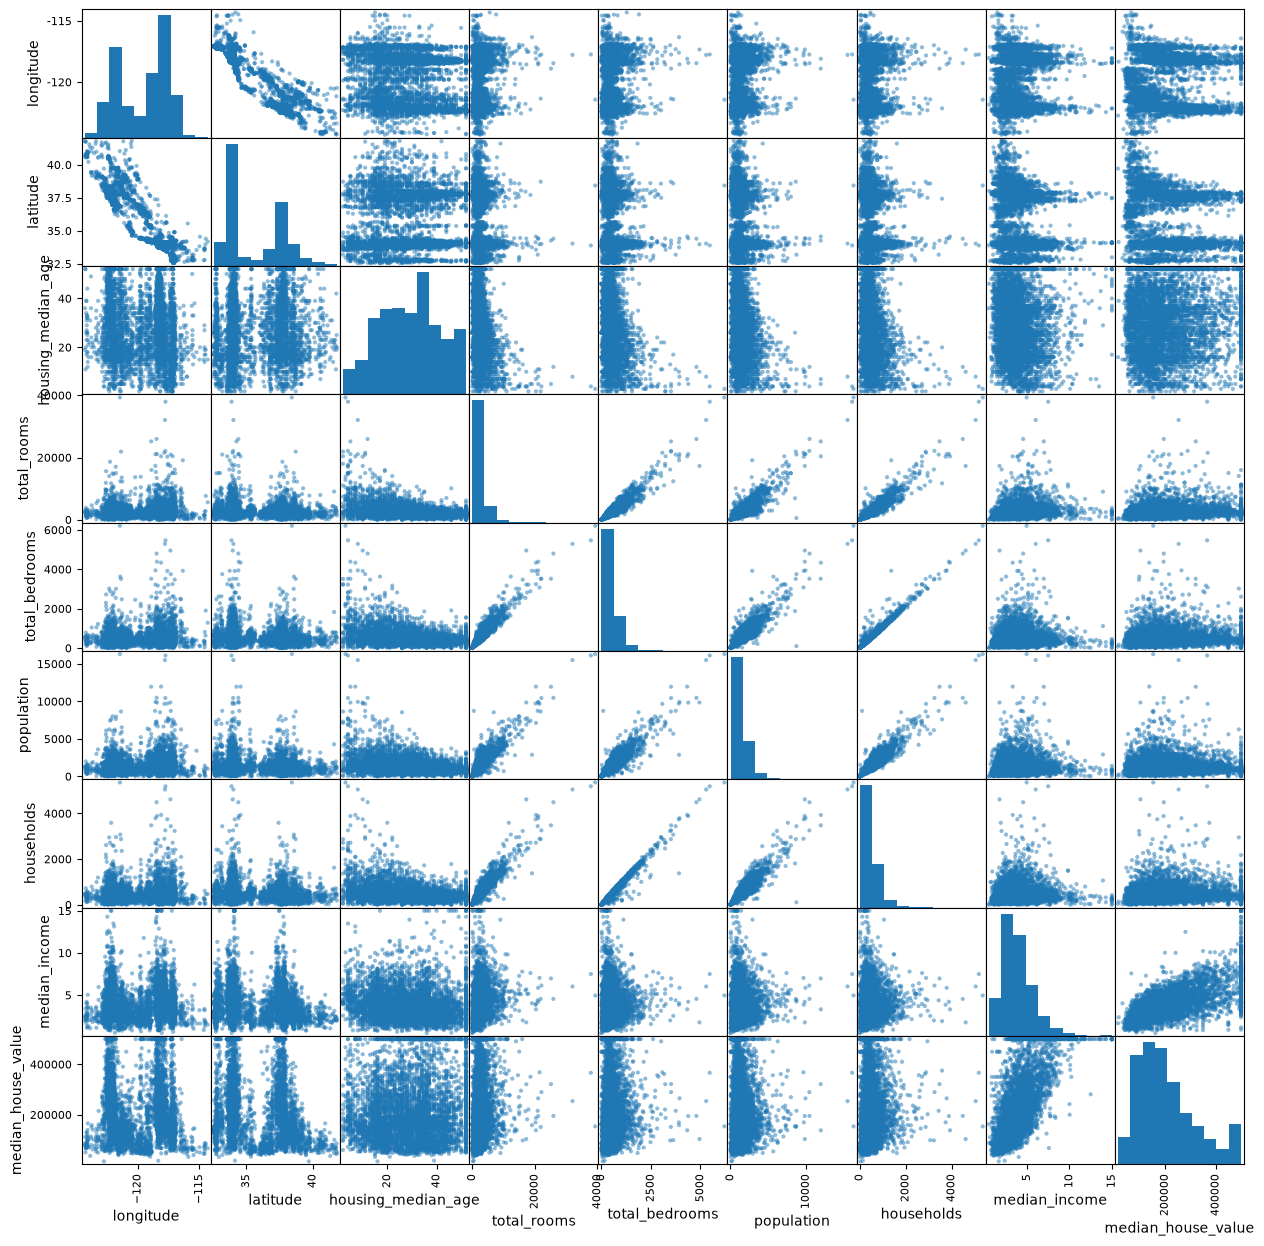

In [3]:
#Answer here
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

sample = df.sample(5000, random_state=42)

scatter_matrix(sample, figsize=(15, 15))
plt.show()

Median income is positively correlated with median housing value, but the data points are relatively scattered.

#### __Exercise 3__

Use a pandas `groupby` operation to calculate the `mean` median house value by proximity to ocean.

In [4]:
#Answer here
df.groupby("ocean_proximity")["median_house_value"].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

#### __Exercise 4__

Plot histograms for median house values for each of the categories in `ocean_proximity`. What do you notice?  Are your histograms normally distributed?  Are there any anomalies?  Why do you think that is? 

Note, in order to get your plot to look a little nicer, you can use matplotlib's layout functions, as follows:

~~~python
import pandas as pd
import matplotlib.pyplot as plt

# Presume we have a data frame df
plt.figure()  # Increase figure size

# This line will change in order to plot different histograms for values of ocean_proximity
# However, including figsize here will help you to get a readable figure
df['column'].plot.hist(figsize=(10, 10))
plt.tight_layout()  # Adjust layout to make room for titles
plt.show()
~~~

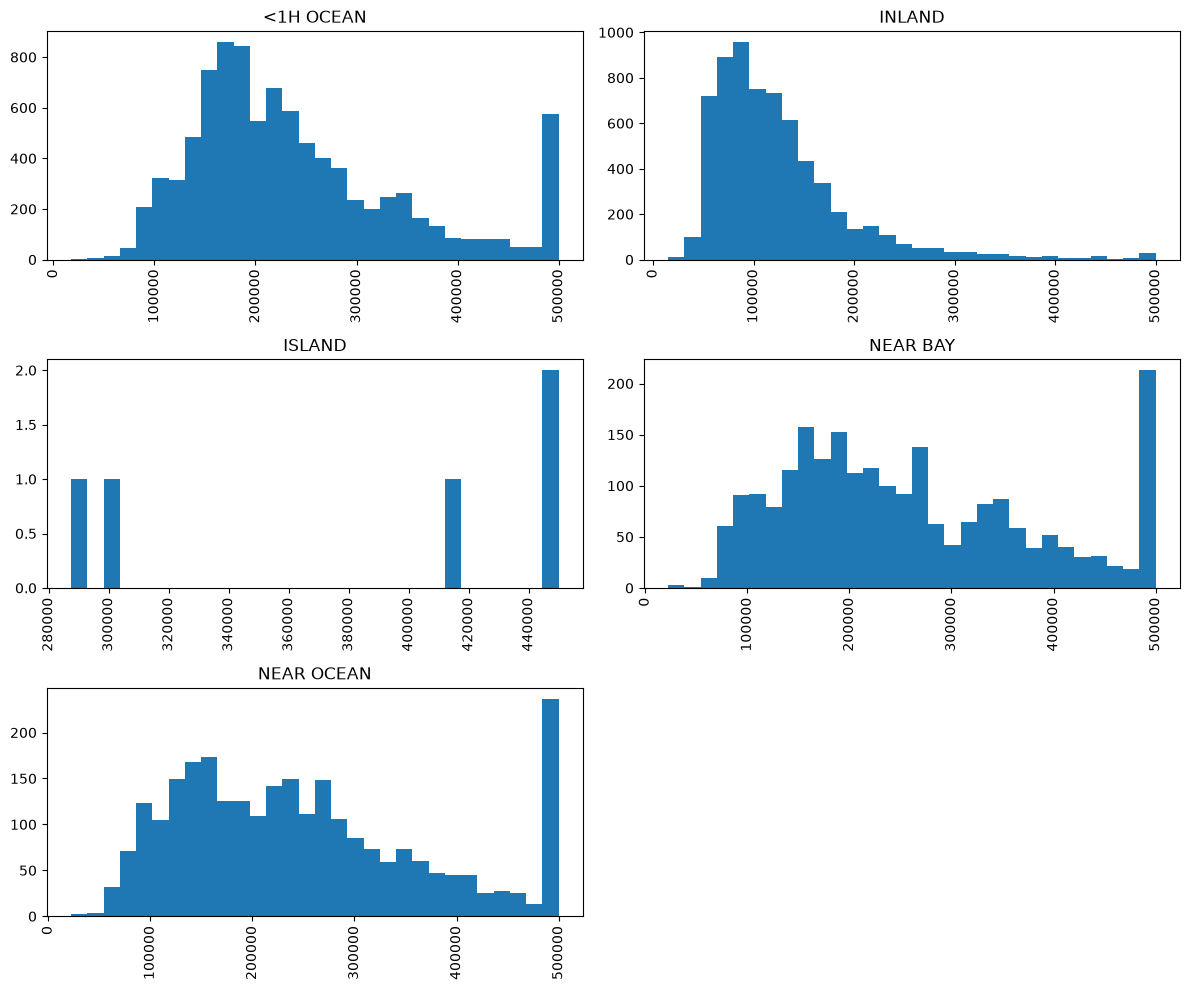

In [12]:
#Answer here
df.hist(
    column="median_house_value",
    by="ocean_proximity",
    bins=30,
    figsize=(12, 10)
)
plt.tight_layout()
plt.show()

The distribution does not fully conform to a normal distribution. The number of high-value houses in certain categories is greater than in others, and there are sharp peaks near the maximum value, indicating that there is an upper limit to house prices.

#### __Exercise 5__

Create a new dataframe by removing all of the rows that have null values anywhere. How many rows did you remove?


In [19]:
#Answer here
df_clean = df.dropna()

print("Rows removed:", len(df) - len(df_clean))

Rows removed: 207


#### __Exercise 6__

Use sklearn to create a linear regression on your cleaned data that predicts `median_house_value` (this is your target column). Do not use the `ocean_proximity` column. Report the intercept and factors.  What do these numbers mean to you?

_HINT1_: You can use pandas' `drop` function to drop the `ocean_proximity` and the target column.
_HINT2_: To figure out which feature each coefficient corresponds to, use the following:

~~~python
# Presuming your result is in the result variable
print("\n".join([f"{x[0]} : {x[1]}" for x in zip(result.feature_names_in_,result.coef_)]))
~~~

In [25]:
#Answer here
from sklearn.linear_model import LinearRegression

X_clean = df_clean.drop(
    columns=["ocean_proximity", "median_house_value"]
)
y_clean = df_clean["median_house_value"]

result_clean = LinearRegression()
result_clean.fit(X_clean, y_clean)

print("Intercept:", result_clean.intercept_)
print("\n".join(
    [f"{x[0]} : {x[1]}" for x in
     zip(result_clean.feature_names_in_, result_clean.coef_)]
))

Intercept: -3585395.747893106
longitude : -42730.12045358983
latitude : -42509.7369418333
housing_median_age : 1157.9003071517707
total_rooms : -8.249725069152191
total_bedrooms : 113.82070712791665
population : -38.38557804964876
households : 47.70135133103122
median_income : 40297.52171480644


#### __Exercise 7__

Note that we had to throw some data away because of the nulls in the data frame. To address this, we'll try manually "imputing" the missing data.  Using pandas, calculate the median value for the column where nulls appeared in your "clean" data.  Then replace the null entries with this median value.

Rerun the regression on with the imputed data. Did anything change?

In [30]:
#Answer here
df_imputed = df.copy()

median_bedrooms = df_imputed["total_bedrooms"].median()
df_imputed["total_bedrooms"] = (
    df_imputed["total_bedrooms"].fillna(median_bedrooms)
)

X_imputed = df_imputed.drop(
    columns=["ocean_proximity", "median_house_value"]
)
y_imputed = df_imputed["median_house_value"]

result_imputed = LinearRegression()
result_imputed.fit(X_imputed, y_imputed)

print("Original intercept:", result_clean.intercept_)
print("Imputed intercept:", result_imputed.intercept_)

print("Original coefficients:", result_clean.coef_)
print("Imputed coefficients:", result_imputed.coef_)

Original intercept: -3585395.747893106
Imputed intercept: -3570118.0614948045
Original coefficients: [-4.27301205e+04 -4.25097369e+04  1.15790031e+03 -8.24972507e+00
  1.13820707e+02 -3.83855780e+01  4.77013513e+01  4.02975217e+04]
Imputed coefficients: [-4.26104026e+04 -4.24754782e+04  1.14445085e+03 -6.62091740e+00
  8.11609666e+01 -3.98732002e+01  7.93047225e+01  3.97522237e+04]


#### __Exercise 8__

We've got some results, but we really don't know how we're doing here.  Use `cross_val_score` with 5 folds to compare the results of the two models.  Which model is better?

_NOTE1_: `cross_val_score` can be found in the `model_selection` library.  Import it like this:

~~~python
from sklearn.model_selection import cross_val_score
~~~

_NOTE2_: You can get the mean value of an array with `np.mean` once you have imported numpy as np.

In [34]:
#Answer here
import numpy as np
from sklearn.model_selection import cross_val_score

clean_scores = cross_val_score(
    LinearRegression(), X_clean, y_clean, cv=5
)

imputed_scores = cross_val_score(
    LinearRegression(), X_imputed, y_imputed, cv=5
)

print("Clean model average:", np.mean(clean_scores))
print("Imputed model average:", np.mean(imputed_scores))

Clean model average: 0.6355815602510868
Imputed model average: 0.6343326831098293


The models with higher average R² values performed better in this comparison.

#### __Exercise 9__

Note that some of your features probably don't have a linear relationship with the data (see your scatter plots).  Using whichever dataset is performs better, drop the features that seem unlikely to have a linear relationship and see if you can get a better model (higher cross val score).  What is the minimum number of features you can use to achieve approximately the same performance?

In [37]:
#Answer here
if np.mean(clean_scores) > np.mean(imputed_scores):
    X_best = X_clean
    y_best = y_clean
    original_score = np.mean(clean_scores)
else:
    X_best = X_imputed
    y_best = y_imputed
    original_score = np.mean(imputed_scores)

for features in [
    ["median_income", "latitude", "longitude"],
    ["median_income", "latitude"],
    ["median_income"]
]:
    scores = cross_val_score(
        LinearRegression(),
        X_best[features],
        y_best,
        cv=5
    )
    print(features, "Average score:", np.mean(scores))

print("Original average score:", original_score)

['median_income', 'latitude', 'longitude'] Average score: 0.5840515747075739
['median_income', 'latitude'] Average score: 0.48179603209538513
['median_income'] Average score: 0.47370983135535305
Original average score: 0.6355815602510868


#### __Exercise 10__

One thing that might help is to get a better sense of the importance of each feature.  Unfortunately, because the features all have different magnitudes, its very hard to make direct comparisons.  Use sklearn's `StandardScaler` (see the book!) to normalize your data before you run your model.  Investigate your coefficients.  Which ones are most important (i.e. have the highest absolute magnitude)?  What have you learned (contrast your answer here with what you found in the previous exercise).

Note - make sure you scale both the target column and the features.

In [39]:
#Answer here
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X_best)
y_scaled = y_scaler.fit_transform(
    y_best.to_numpy().reshape(-1, 1)
).ravel()

scaled_result = LinearRegression()
scaled_result.fit(X_scaled, y_scaled)

for feature, coefficient in zip(X_best.columns, scaled_result.coef_):
    print(feature, ":", coefficient)

longitude : -0.7416522705830051
latitude : -0.7867202537709262
housing_median_age : 0.12630459439155994
total_rooms : -0.1561724688968377
total_bedrooms : 0.4154898382318361
population : -0.37682342055056667
households : 0.15797708061795462
median_income : 0.6630249756021853


The feature corresponding to the coefficient with the largest absolute value has the strongest correlation with the prediction result. Compare this ranking with the features retained in Exercise 9; the correlated features may affect each other's coefficients.